In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

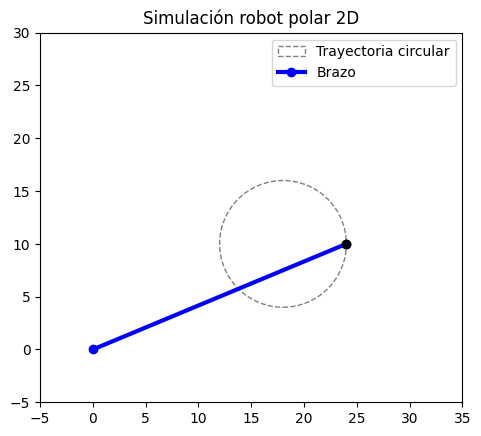

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Parámetros del robot
# -----------------------------
L_min = 20.0  # cm
L_max = 28.0  # cm
alpha_max = np.deg2rad(45)  # rad

# -----------------------------
# Funciones cinemáticas
# -----------------------------
def L(alpha):
    """Longitud del brazo en función del ángulo del servo (rad)."""
    return L_min + (alpha / alpha_max) * (L_max - L_min)

def fk(theta, alpha):
    """Cinemática directa: devuelve (x,y)."""
    l = L(alpha)
    x = l * np.cos(theta)
    y = l * np.sin(theta)
    return x, y

def ik(x, y):
    """Cinemática inversa: dado (x,y), devuelve (theta, alpha)."""
    r = np.sqrt(x**2 + y**2)
    if r < L_min or r > L_max:
        raise ValueError("Punto fuera del espacio de trabajo")
    theta = np.arctan2(y, x)
    alpha = (r - L_min) / (L_max - L_min) * alpha_max
    return theta, alpha

# -----------------------------
# Trayectoria circular
# -----------------------------
t = np.linspace(0, 2*np.pi, 200)
radius = 6      # radio del círculo
cx, cy = 18, 10 # centro del círculo

traj_x = cx + radius * np.cos(t)
traj_y = cy + radius * np.sin(t)

# -----------------------------
# Animación
# -----------------------------
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_xlim(-5, 35)
ax.set_ylim(-5, 30)
ax.set_title("Simulación robot polar 2D")

# Dibujar círculo de referencia
circle = plt.Circle((cx, cy), radius, color='gray', fill=False, linestyle='--', label='Trayectoria circular')
ax.add_patch(circle)

# Brazo
line, = ax.plot([], [], 'bo-', lw=3, label="Brazo")
point, = ax.plot([], [], 'ko', markersize=6)

# Funciones de animación
def init():
    line.set_data([], [])
    point.set_data([], [])
    return line, point

def update(frame):
    xd, yd = traj_x[frame], traj_y[frame]
    try:
        theta, alpha = ik(xd, yd)
        x, y = fk(theta, alpha)
        line.set_data([0, x], [0, y])
        point.set_data([x], [y])
    except ValueError:
        line.set_data([], [])
        point.set_data([], [])
    return line, point

ani = FuncAnimation(fig, update, frames=len(traj_x), init_func=init,
                    blit=True, interval=100, repeat=True)

plt.legend()

# Mostrar animación en HTML
HTML(ani.to_jshtml())


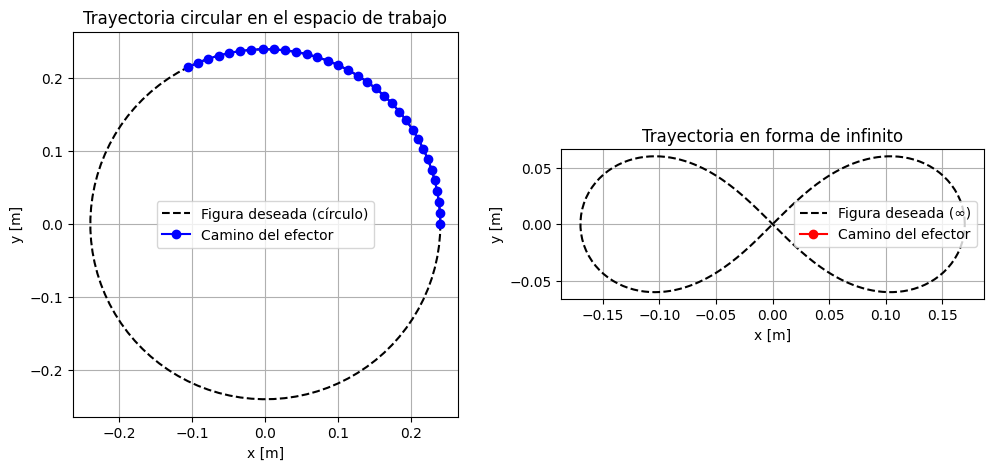

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del robot polar
L_min = 0.20  # m
L_max = 0.28  # m
alpha_max = np.deg2rad(45)

# Cinemática directa
def fk(theta, alpha):
    L = L_min + (alpha/alpha_max)*(L_max - L_min)
    x = L * np.cos(theta)
    y = L * np.sin(theta)
    return x, y

# Cinemática inversa
def ik(x, y):
    r = np.sqrt(x**2 + y**2)
    ang = np.arctan2(y, x)
    if r < L_min or r > L_max or ang < 0 or ang > np.deg2rad(120):
        return None, None  # punto no alcanzable
    theta = ang
    alpha = alpha_max * (r - L_min) / (L_max - L_min)
    return theta, alpha

# Trayectoria círculo
def trayectoria_circulo(radio=0.24, n_puntos=100):
    t = np.linspace(0, 2*np.pi, n_puntos)
    x = radio * np.cos(t)
    y = radio * np.sin(t)
    return x, y

# Trayectoria infinito (lemniscata)
def trayectoria_infinito(a=0.12, n_puntos=200):
    t = np.linspace(0, 2*np.pi, n_puntos)
    x = (a * np.sqrt(2) * np.cos(t)) / (np.sin(t)**2 + 1)
    y = (a * np.sqrt(2) * np.cos(t) * np.sin(t)) / (np.sin(t)**2 + 1)
    return x, y

# Función para simular trayectorias
def simular_trayectoria(x_ref, y_ref):
    x_real, y_real = [], []
    for xd, yd in zip(x_ref, y_ref):
        theta, alpha = ik(xd, yd)
        if theta is not None:  # alcanzable
            xr, yr = fk(theta, alpha)
            x_real.append(xr)
            y_real.append(yr)
    return np.array(x_real), np.array(y_real)

# Generar trayectorias
circ_x, circ_y = trayectoria_circulo()
inf_x, inf_y = trayectoria_infinito()

# Simular caminos alcanzados
circ_real_x, circ_real_y = simular_trayectoria(circ_x, circ_y)
inf_real_x, inf_real_y = simular_trayectoria(inf_x, inf_y)

# Graficar círculo
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(circ_x, circ_y, 'k--', label="Figura deseada (círculo)")
plt.plot(circ_real_x, circ_real_y, 'bo-', label="Camino del efector")
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trayectoria circular en el espacio de trabajo")
plt.legend()
plt.grid(True)

# Graficar infinito
plt.subplot(1,2,2)
plt.plot(inf_x, inf_y, 'k--', label="Figura deseada (∞)")
plt.plot(inf_real_x, inf_real_y, 'ro-', label="Camino del efector")
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trayectoria en forma de infinito")
plt.legend()
plt.grid(True)

plt.show()


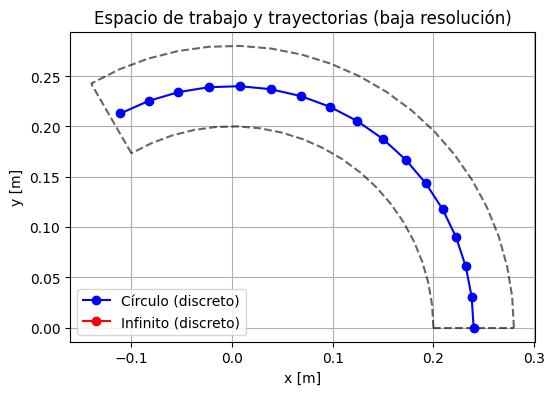

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del robot polar
L_min = 0.20  # m
L_max = 0.28  # m

# Trayectoria 1: círculo dentro del workspace
t = np.linspace(0, 2*np.pi, 50)   # pocos puntos
circle_r = 0.24
circle_x = circle_r*np.cos(t)
circle_y = circle_r*np.sin(t)

# Trayectoria 2: signo de infinito (lemniscata)
a = 0.12
lem_t = np.linspace(0, 2*np.pi, 80)  # pocos puntos
lem_x = (a * np.sqrt(2) * np.cos(lem_t)) / (np.sin(lem_t)**2 + 1)
lem_y = (a * np.sqrt(2) * np.cos(lem_t) * np.sin(lem_t)) / (np.sin(lem_t)**2 + 1)

# Filtrar puntos dentro del workspace
def filter_workspace(x, y):
    r = np.sqrt(x**2 + y**2)
    ang = np.arctan2(y, x)
    mask = (r >= L_min) & (r <= L_max) & (ang >= 0) & (ang <= np.deg2rad(120))
    return x[mask], y[mask]

circle_x, circle_y = filter_workspace(circle_x, circle_y)
lem_x, lem_y = filter_workspace(lem_x, lem_y)

# Graficar
plt.figure(figsize=(6,6))

# Arcos de workspace con baja resolución
arc_theta = np.linspace(0, np.deg2rad(120), 20)
plt.plot(L_min*np.cos(arc_theta), L_min*np.sin(arc_theta), 'k--', alpha=0.6)
plt.plot(L_max*np.cos(arc_theta), L_max*np.sin(arc_theta), 'k--', alpha=0.6)

# Líneas radiales
plt.plot([L_min*np.cos(0), L_max*np.cos(0)], [L_min*np.sin(0), L_max*np.sin(0)], 'k--', alpha=0.6)
plt.plot([L_min*np.cos(np.deg2rad(120)), L_max*np.cos(np.deg2rad(120))],
         [L_min*np.sin(np.deg2rad(120)), L_max*np.sin(np.deg2rad(120))], 'k--', alpha=0.6)

# Trayectorias
plt.plot(circle_x, circle_y, 'bo-', label="Círculo (discreto)")
plt.plot(lem_x, lem_y, 'ro-', label="Infinito (discreto)")

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Espacio de trabajo y trayectorias (baja resolución)")
plt.legend()
plt.grid(True)
plt.show()


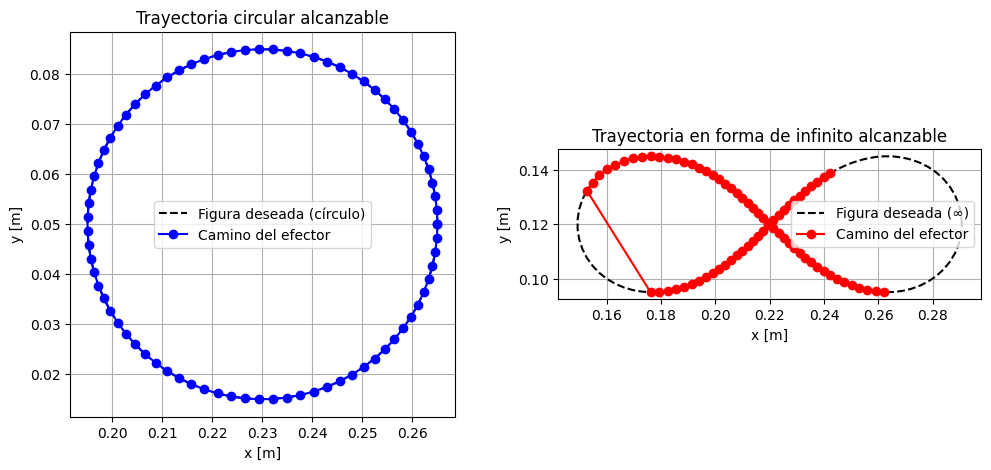

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del robot polar
L_min = 0.20  # m
L_max = 0.28  # m
alpha_max = np.deg2rad(45)

# Cinemática directa
def fk(theta, alpha):
    L = L_min + (alpha/alpha_max)*(L_max - L_min)
    x = L * np.cos(theta)
    y = L * np.sin(theta)
    return x, y

# Cinemática inversa
def ik(x, y):
    r = np.sqrt(x**2 + y**2)
    ang = np.arctan2(y, x)
    if r < L_min or r > L_max or ang < 0 or ang > np.deg2rad(120):
        return None, None  # punto no alcanzable
    theta = ang
    alpha = alpha_max * (r - L_min) / (L_max - L_min)
    return theta, alpha

# Trayectoria círculo (trasladada y escalada)
def trayectoria_circulo(radio=0.035, centro=(0.23, 0.05), n_puntos=80):
    t = np.linspace(0, 2*np.pi, n_puntos)
    x = centro[0] + radio * np.cos(t)
    y = centro[1] + radio * np.sin(t)
    return x, y

# Trayectoria infinito (trasladada y escalada)
def trayectoria_infinito(a=0.05, centro=(0.22, 0.12), n_puntos=120):
    t = np.linspace(0, 2*np.pi, n_puntos)
    x = (a * np.sqrt(2) * np.cos(t)) / (np.sin(t)**2 + 1)
    y = (a * np.sqrt(2) * np.cos(t) * np.sin(t)) / (np.sin(t)**2 + 1)
    # Trasladar al centro
    return centro[0] + x, centro[1] + y

# Simulación de trayectorias
def simular_trayectoria(x_ref, y_ref):
    x_real, y_real = [], []
    for xd, yd in zip(x_ref, y_ref):
        theta, alpha = ik(xd, yd)
        if theta is not None:  # alcanzable
            xr, yr = fk(theta, alpha)
            x_real.append(xr)
            y_real.append(yr)
    return np.array(x_real), np.array(y_real)

# Generar trayectorias
circ_x, circ_y = trayectoria_circulo()
inf_x, inf_y = trayectoria_infinito()

# Simular caminos alcanzados
circ_real_x, circ_real_y = simular_trayectoria(circ_x, circ_y)
inf_real_x, inf_real_y = simular_trayectoria(inf_x, inf_y)

# Graficar
plt.figure(figsize=(12,5))

# Gráfico círculo
plt.subplot(1,2,1)
plt.plot(circ_x, circ_y, 'k--', label="Figura deseada (círculo)")
plt.plot(circ_real_x, circ_real_y, 'bo-', label="Camino del efector")
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trayectoria circular alcanzable")
plt.legend()
plt.grid(True)

# Gráfico infinito
plt.subplot(1,2,2)
plt.plot(inf_x, inf_y, 'k--', label="Figura deseada (∞)")
plt.plot(inf_real_x, inf_real_y, 'ro-', label="Camino del efector")
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trayectoria en forma de infinito alcanzable")
plt.legend()
plt.grid(True)

plt.show()
